In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mysklearn.mypytable import MyPyTable
from mysklearn.myutils import *

In [18]:
CLASSES = ["Pastry","Z_Scratch","K_Scratch","Stains","Dirtiness","Bumps","Other_Faults"]

data = MyPyTable().load_from_file("plate-data.csv")

data = onehot_to_categorical(data, CLASSES)
# data.pretty_print()
print(data.column_names)

['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Class']


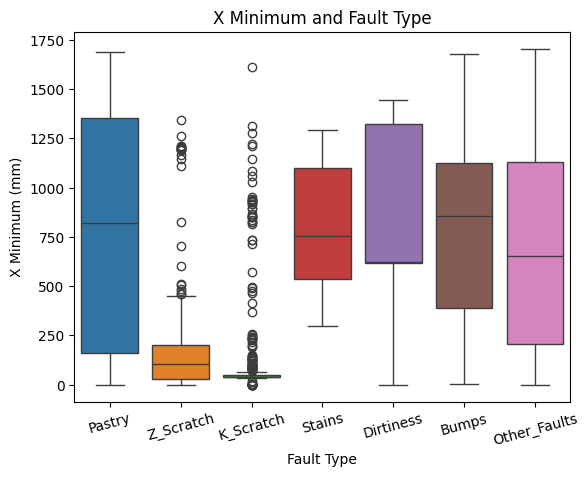

In [19]:
sns.boxplot(data=eda_group_data_by_class(data, "X_Minimum"))
plt.xticks(rotation=15)
plt.title("X Minimum and Fault Type")
plt.xlabel("Fault Type")
plt.ylabel("X Minimum (mm)")
plt.show()

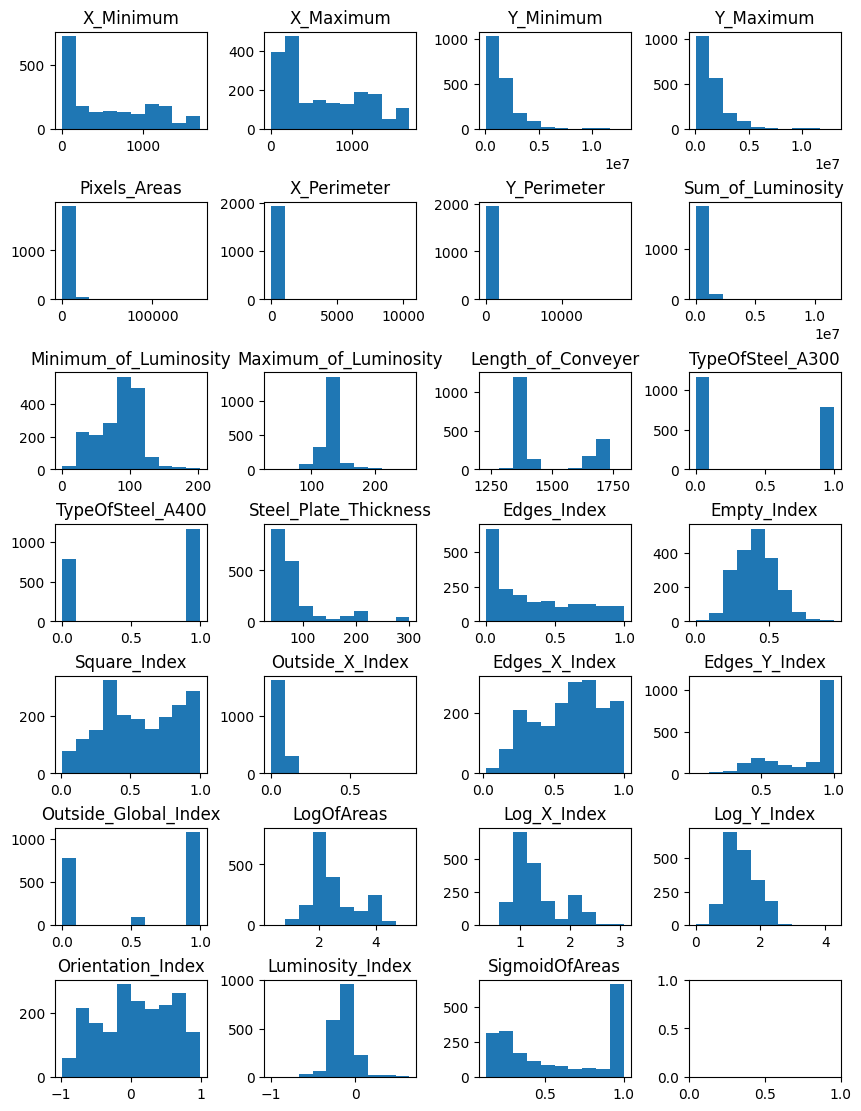

In [20]:
import copy
col_count = 4

tmp_classes = copy.deepcopy(data.column_names)
tmp_classes.remove('Class')
tmp_fig, ax = plt.subplots((len(tmp_classes)//col_count)+1, col_count, layout='constrained', figsize=(8,8))
tmp_fig.set_size_inches(8.5, 11)
for col in range(len(tmp_classes)):
    tmp = ax.flat[col]
    tmp.hist(data.get_column(data.column_names[col]))
    tmp.set_title(data.column_names[col])

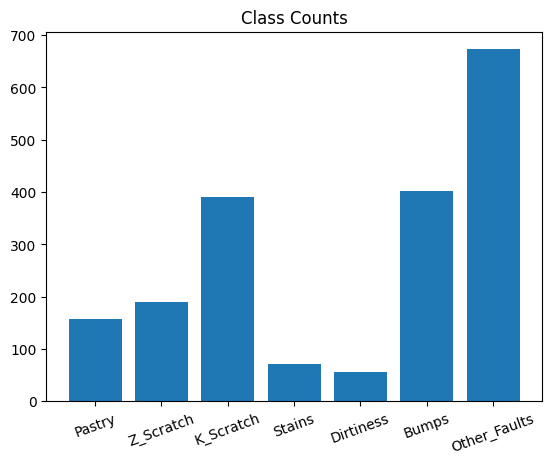

In [21]:
counts = {k: 0 for k in CLASSES}
for result in data.get_column('Class'):
    counts[result]+=1

fig, ax = plt.subplots()
ax.set_title("Class Counts")
ax.bar(counts.keys(), counts.values())
ax.tick_params('x', rotation=20)